<a href="https://colab.research.google.com/github/imaisnaini/data-science-2026/blob/main/Pertemuan7_Fatimah_Isnaini_Shabrina__250401020073.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#📚 **Practice 7 : Regresi Linear**
---
##👩‍🎓 **Student Information**
- **Name**: Fatimah Isnaini Shabrina
- **NIM**: 250401020073
- **University**: UNSIA - Universitas Siber Asia
- **Class**: IF401 Data Science
---
### Langkah 1 : Generate & Eksplorasi Dataset

Shape: (300, 4)
       pengalaman     edu    gaji
count      300.00  300.00  300.00
mean         9.90    0.89   27.40
std          5.89    0.83   13.41
min          0.10    0.00    1.67
25%          4.78    0.00   16.24
50%         10.23    1.00   27.97
75%         15.14    2.00   38.89
max         19.80    2.00   54.22


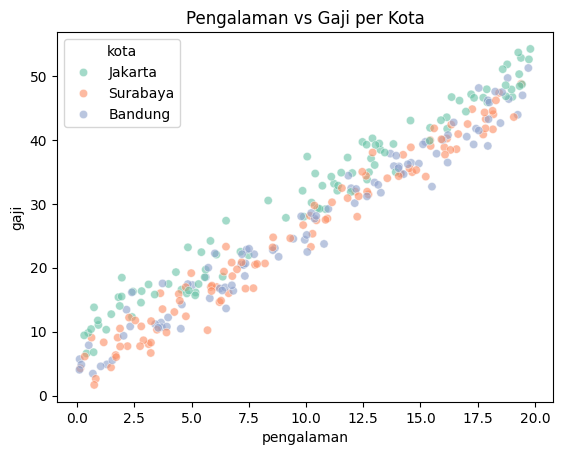

In [ ]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns

# Generate dataset sintetis
np.random.seed(42); n = 300
pengalaman  = np.random.uniform(0, 20, n)
edu         = np.random.choice([0, 1, 2], n) # SMA=0, D3=1, S1=2
kota        = np.random.choice(['Jakarta', 'Surabaya', 'Bandung'], n)
gaji        = (3.0 + 2.2*pengalaman + 1.5*edu
               + np.where(kota=='Jakarta', 4.0, 0)
               + np.random.normal(0, 2, n))
df = pd.DataFrame({'pengalaman': pengalaman,
                     'edu': edu,
                     'kota': kota,
                     'gaji': gaji})

# EDA singkat
print('Shape:', df.shape)
print(df.describe().round(2))

# Scatter: pengalaman vs gaji
sns.scatterplot(x='pengalaman', y='gaji', data=df,
                hue='kota', palette='Set2', alpha=0.6)
plt.title('Pengalaman vs Gaji per Kota')
plt.show()



### Interpretasi
Pada praktikum kali ini kita belajar membuat data contoh sendiri untuk latihan. Data mencakup informasi seperti 'pengalaman kerja', 'tingkat pendidikan' (misalnya SMA, D3, S1), 'kota tempat tinggal', dan 'gaji'. Kita juga membuat `scatterplot` untuk melihat bagaimana 'pengalaman' memengaruhi 'gaji', dan apakah ada perbedaan jika dilihat dari 'kota' tempat bekerja.

### Langkah 2 : Preprocessing

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# One-Hot Encoding kolom 'Kota'
df = pd.get_dummies(df, columns=['kota'], drop_first=True, dtype=int)
print('Kolom setelah encoding:', df.columns.tolist())

# Pisahkan fitur dan target
x = df.drop('gaji', axis=1)
y = df['gaji']

# Split data menjadi train dan test
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42)
print('Shape train  :', x_train.shape, y_train.shape)
print('Shape test   :', x_test.shape, y_test.shape)

# StandardScaler - fit pada training set saja
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test  = scaler.transform(x_test)

Kolom setelah encoding: ['pengalaman', 'edu', 'gaji', 'kota_Jakarta', 'kota_Surabaya']
Shape train  : (240, 4) (240,)
Shape test   : (60, 4) (60,)


### Interpretasi
Langkah ini adalah tahap persiapan data sebelum data digunakan untuk melatih model dengan cara :
1. Encoding data kategorikal
2. Memisahkan fitur (x) dan target (y)
3. Membagi data menjadi train set dan test set
4. Melakukan standarisasi

### Langkah 3 : Latih Model & Tampilkan Koefisien

In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(x_train, y_train)

# Tampilkan koefisien
print(f'β0 (intercept): {model.intercept_:.3f}')
print()
coef_df = pd.DataFrame({
    'Feature': x.columns.tolist(),
    'Coefficient': model.coef_.round(3)
}).sort_values('Coefficient', ascending=False)
print(coef_df.to_string(index=False))

# Interpretasi : fitur mana yang paling berpengaruh?
# Koefisien positif -> gaji naik
# Koefisien negatif -> gaji turun

β0 (intercept): 27.514

      Feature  Coefficient
   pengalaman       13.042
 kota_Jakarta        1.837
          edu        1.188
kota_Surabaya       -0.292


### Interpretasi
Di tahap ini, kita melatih model regresi linear (`LinearRegression`) menggunakan data training yang sudah kita siapkan. Model ini akan belajar hubungan antara fitur-fitur dan gaji. Setelah model selesai dilatih, kita akan melihat 'koefisien' dari model tersebut. Koefisien ini menunjukkan seberapa besar pengaruh setiap fitur terhadap nilai gaji yang diprediksi. Misalnya, koefisien positif berarti peningkatan pada fitur tersebut akan cenderung meningkatkan gaji, sementara koefisien negatif menunjukkan efek sebaliknya. Dari sini, kita bisa mengidentifikasi fitur mana yang paling signifikan dalam memprediksi gaji.

### Langkah 4 : Evaluasi Model

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Evaluasi model
y_pred  = model.predict(x_test)
mse     = mean_absolute_error(y_test, y_pred)
rmse    = mean_squared_error(y_test, y_pred)
r2      = r2_score(y_test, y_pred)

print('=== Metrik Evaluasi ===')
print(f'MSE   : {mse:.3f} juta rupiah')
print(f'RMSE  : {rmse:.3f} juta rupiah')
print(f'R^2   : {r2:.4f} ((r2*100:.1f)% variasi dijelaskan) ')
print(f'Selisih RMSE-MAE = (rmse-mae:.3f)')

# Interprestasikan dalam Markdown sel berikutnya :
# - Berapa rata-rata kesalahan prediksi dalam rupiah?
# - Apakah R^2 cukup baik untuk kasus ini?
# - Apakah ada indikasi outliner?

=== Metrik Evaluasi ===
MSE   : 1.649 juta rupiah
RMSE  : 4.507 juta rupiah
R^2   : 0.9740 ((r2*100:.1f)% variasi dijelaskan) 
Selisih RMSE-MAE = (rmse-mae:.3f)


### Interpretasi
Setelah model dilatih, dilakukan evaluasi menggunakan beberapa metrik:
- **MAE (Mean Absolute Error) sebesar 1.649 juta rupiah:** Metrik ini memberitahu kita rata-rata selisih absolut antara gaji aktual dan gaji yang diprediksi oleh model. Secara rata-rata, model meleset sekitar 1.649 juta rupiah dalam prediksinya.
- **RMSE (Root Mean Squared Error) sebesar 4.507 juta rupiah:** Ini adalah metrik kesalahan yang juga mengukur selisih antara nilai aktual dan prediksi, namun lebih sensitif terhadap kesalahan yang besar (outlier). Ada selisih yang cukup signifikan antara RMSE dan MAE (sekitar 2.858 juta rupiah) mengindikasikan bahwa ada beberapa prediksi model yang sangat jauh dari nilai aktual, mungkin karena adanya outlier dalam data.
- **R² (R-squared) sebesar 0.9740:** Nilai ini menunjukkan seberapa besar variasi dalam gaji dapat dijelaskan oleh model kita.

### Langkah 5 : Visualisasi & Interpretasi

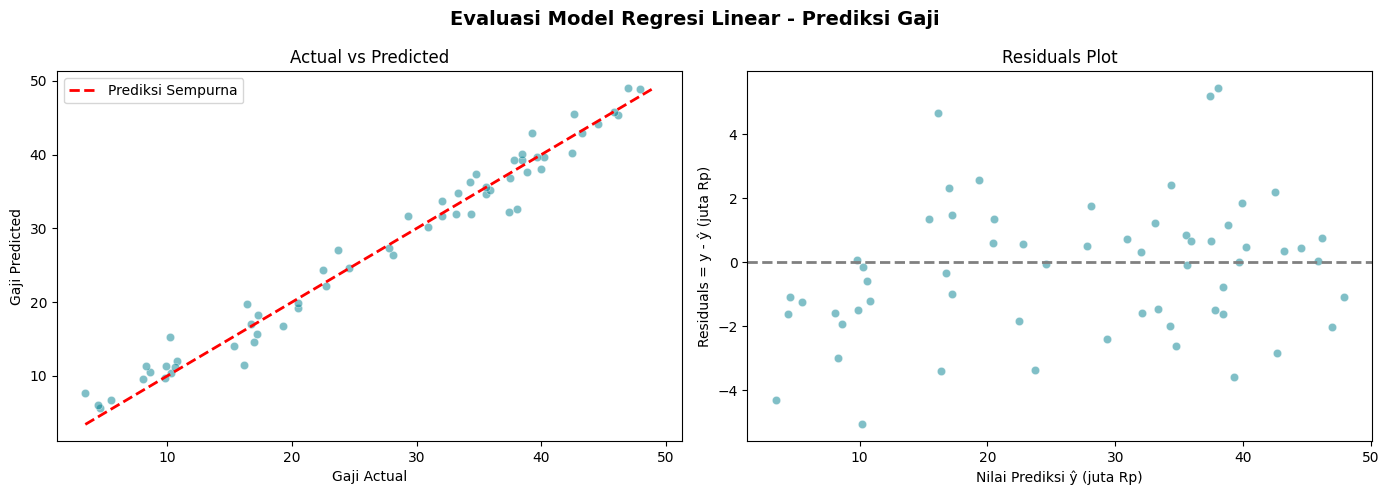

In [ ]:
fig, axes = plt.subplots(1,2, figsize=(14, 5))

# Plot 1: Actual vs Predicted
axes[0].scatter(y_test, y_pred, alpha=0.5,
                color='#028090', edgecolors='white', lw=0.5)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
axes[0].plot(lims, lims, 'r--', lw=2, label='Prediksi Sempurna')
axes[0].set_xlabel('Gaji Actual')
axes[0].set_ylabel('Gaji Predicted')
axes[0].set_title('Actual vs Predicted')
axes[0].legend()

# Plot 2: Residuals
residuals = y_test - y_pred
axes[1].scatter(y_test, residuals, alpha=0.5,
                color='#028090', edgecolors='white', lw=0.5)
axes[1].axhline(y=0, color='gray', linestyle='--', lw=2)
axes[1].set_xlabel('Nilai Prediksi ŷ (juta Rp)')
axes[1].set_ylabel('Residuals = y - ŷ (juta Rp)')
axes[1].set_title('Residuals Plot')

plt.suptitle('Evaluasi Model Regresi Linear - Prediksi Gaji',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Cara membaca Residual Plot:
# ✅ Baik: titik tersebar ACAK di sekitar garis y=0
# ❌ Masalah: ada pola (kurva, corong) → asumsi linearitas dilanggar

### Interpretasi
**What?**

Model regresi linear digunakan untuk memprediksi gaji berdasarkan fitur yang tersedia.

**So What?**

Nilai prediksi sangat dekat dengan nilai aktual.
Residual tersebar acak di sekitar nol.
Tidak ditemukan indikasi kuat pelanggaran asumsi linearitas.

**Now What?**

Model dapat digunakan sebagai alat prediksi gaji yang cukup baik. Evaluasi lanjutan menggunakan metrik performa (R², MAE, RMSE) dan penambahan fitur yang relevan dapat dilakukan untuk meningkatkan kualitas prediksi.

## 📝 Notes :

Pada praktikum ini telah dipelajari proses membangun model **Regresi Linear** mulai dari eksplorasi data, preprocessing (encoding, pembagian data, dan normalisasi), pelatihan model, hingga evaluasi hasil prediksi.

Model berhasil digunakan untuk memprediksi nilai gaji berdasarkan fitur-fitur yang tersedia. Hasil evaluasi menunjukkan bahwa prediksi model cukup dekat dengan nilai aktual dan residual tersebar secara acak di sekitar nol, sehingga model mampu menangkap hubungan linear pada data dengan baik.